# Plot Comparison Results

## Define Data Loader

In [1]:
from collections import namedtuple
import numpy as np
from matplotlib import pyplot as plt

Particle = namedtuple('Particle', ['m', 'r', 'v'])

def load(name):
    E = np.loadtxt(name+'.eng')
    
    with open(name + '.dat') as f:
        n = int(next(f))
        d = np.loadtxt(f)
        l = len(d) // n
        d = d[:l*n,:].reshape((l, n, 7))

    return E, [Particle(m=d[0,i,0], r=d[:,i,1:4], v=d[:,i,4:7]) for i in range(n)]

## Check Output from the Chin (1997) C Algorithm

In [2]:
E, ps = load('../ChinC')

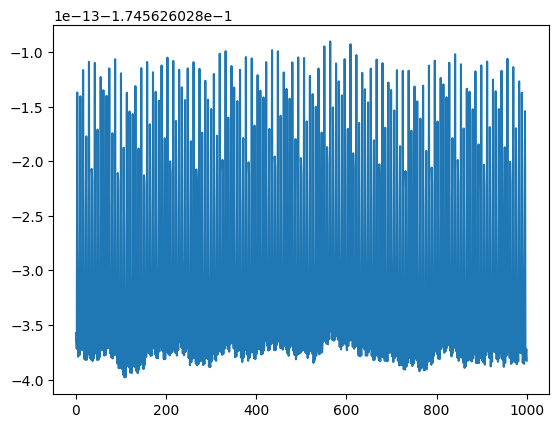

In [3]:
plt.plot(E)

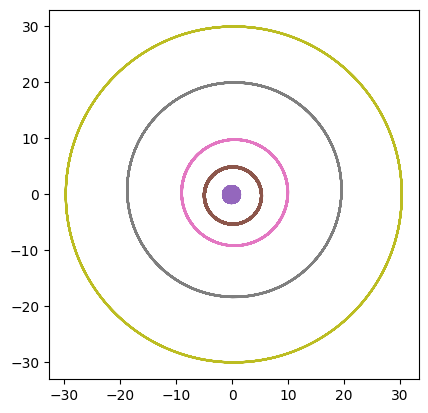

In [4]:
for p in ps:
    plt.plot(p.r[:,0], p.r[:,1])
    
plt.gca().set_aspect('equal')

## Compare Outputs

In [5]:
from glob import glob
from os.path import basename, splitext

In [6]:
names = [splitext(basename(f))[0] for f in glob("../*.dat")]
db    = {n:load('../'+n) for n in names}

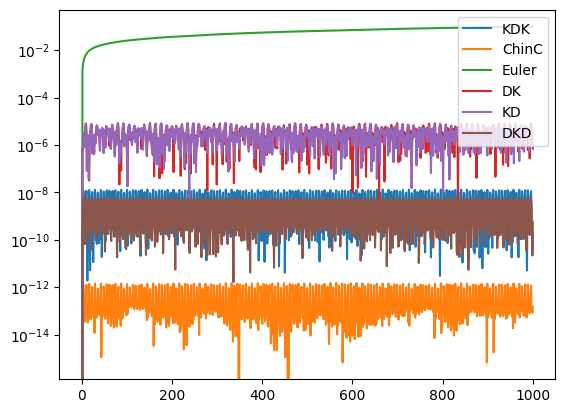

In [7]:
for k, (E, ps) in db.items():
    rerr = E/E[0] - 1
    plt.semilogy(abs(rerr), label=k)

plt.legend(loc='upper right')